In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report

In [13]:
sdir=r'D:\Skripsi\model\dataset'

filepaths=[]
labels=[]
classlist=os.listdir(sdir)
for klass in classlist:
    classpath=os.path.join(sdir,klass)
    if os.path.isdir(classpath):
        flist=os.listdir(classpath)
        for f in flist:
            fpath=os.path.join(classpath,f)
            filepaths.append(fpath)
            labels.append(klass)                   
Fseries= pd.Series(filepaths, name='filepaths')
Lseries=pd.Series(labels, name='labels')    
df=pd.concat([Fseries, Lseries], axis=1)
print (df.head())
print (df['labels'].value_counts())

train_split=.8
test_split=.1
dummy_split=test_split/(1-train_split)
train_df, dummy_df=train_test_split(df, train_size=train_split, shuffle=True, random_state=123)
test_df, valid_df=train_test_split(dummy_df, train_size=dummy_split, shuffle=True, random_state=123)
print ('train_df length: ', len(train_df), '  test_df length: ', len(test_df), '  valid_df length: ', len(valid_df))


                                       filepaths labels
0  D:\Skripsi\model\dataset\botol\botol_1000.png  botol
1  D:\Skripsi\model\dataset\botol\botol_1001.png  botol
2  D:\Skripsi\model\dataset\botol\botol_1002.png  botol
3  D:\Skripsi\model\dataset\botol\botol_1003.png  botol
4  D:\Skripsi\model\dataset\botol\botol_1004.png  botol
labels
botol      710
kaleng     710
kardus     710
organik    710
Name: count, dtype: int64
train_df length:  2272   test_df length:  284   valid_df length:  284


In [14]:
height=299
width=299
channels=3
batch_size=32

In [15]:
img_shape=(height, width, channels)
img_size=(height, width)
length=len(test_df)
test_batch_size=sorted([int(length/n) for n in range(1,length+1) if length % n ==0 and length/n<=80],reverse=True)[0]  
test_steps=int(length/test_batch_size)
print ( 'test batch size: ' ,test_batch_size, '  test steps: ', test_steps)

test batch size:  71   test steps:  4


In [16]:
gen = ImageDataGenerator(
    rescale=1.0 / 255,
    horizontal_flip=True,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    )
train_gen = gen.flow_from_dataframe(
    train_df, 
    x_col='filepaths', 
    y_col='labels', 
    target_size=img_size, 
    class_mode='categorical', 
    color_mode='rgb', 
    shuffle=True, 
    batch_size=batch_size)
validgen = ImageDataGenerator(rescale=1./255)
valid_gen = validgen.flow_from_dataframe(
    valid_df, 
    x_col='filepaths', 
    y_col='labels', 
    target_size=img_size, 
    class_mode='categorical', 
    color_mode='rgb', 
    shuffle=True, 
    batch_size=batch_size)
testgen = ImageDataGenerator(rescale=1./255)
test_gen = testgen.flow_from_dataframe(
    test_df, 
    x_col='filepaths', 
    y_col='labels', 
    target_size=img_size, 
    class_mode='categorical', 
    color_mode='rgb', 
    shuffle=False, 
    batch_size=test_batch_size)

classes=list(train_gen.class_indices.keys())
print (classes)
class_count=len(classes)


Found 2272 validated image filenames belonging to 4 classes.
Found 284 validated image filenames belonging to 4 classes.
Found 284 validated image filenames belonging to 4 classes.
['botol', 'kaleng', 'kardus', 'organik']


In [17]:
base_model = InceptionV3(weights='imagenet',
                         include_top=False, input_shape=(299, 299, 3))
base_model.summary()


Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 149, 149,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 149, 149,  │         96 │ conv2d_95[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_94       │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 147, 147,  │      9,216 │ activation_94[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_96[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_95       │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 147, 147,  │     18,432 │ activation_95[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_97[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_96       │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 73, 73,    │          0 │ activation_96[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, 73, 73,    │      5,120 │ max_pooling2d_5[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_98[0][0]   │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_97       │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_99 (Conv2D)  │ (None, 71, 71,    │    138,240 │ activation_97[0]… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_99[0][0]   │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_98       │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 21,768,352 (83.04 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [18]:
# Build the model with Conv2D after InceptionV3
model = tf.keras.Sequential([
    base_model,  # InceptionV3 base model
    tf.keras.layers.Conv2D(filters=32, padding='same', kernel_size=3, activation='relu', strides=1),
    tf.keras.layers.MaxPool2D(pool_size=2, strides=2),
    tf.keras.layers.Dropout(rate=0.3),
    
    tf.keras.layers.GlobalAveragePooling2D(),  # Add GAP to reduce dimensions
    tf.keras.layers.Dense(4, activation='softmax')  # Output layer for 4 classes
])
base_model.trainable = False  # freeze pretrained

model.summary()
# Mengambil bobot dan bias dari layer Dense terakhir
weights, biases = model.layers[-1].get_weights()

print("Bobot shape:", weights.shape)
print("Bias shape:", biases.shape)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_189 (Conv2D)             │ (None, 8, 8, 32)       │       589,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,392,772 (85.42 MB)

 Trainable params: 589,988 (2.25 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

Bobot shape: (32, 4)
Bias shape: (4,)


In [23]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
epochs = 40
history = model.fit(x=train_gen, epochs=epochs, validation_data=valid_gen, callbacks=[early_stopping])


Epoch 1/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.9626 - loss: 0.1217 - val_accuracy: 0.9542 - val_loss: 0.1691
Epoch 2/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.9837 - loss: 0.0438 - val_accuracy: 0.9824 - val_loss: 0.0469
Epoch 3/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.9908 - loss: 0.0267 - val_accuracy: 0.9824 - val_loss: 0.0288
Epoch 4/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.9925 - loss: 0.0267 - val_accuracy: 0.9824 - val_loss: 0.0444
Epoch 5/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.9952 - loss: 0.0170 - val_accuracy: 0.9894 - val_loss: 0.0327
Epoch 6/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.9934 - loss: 0.0210 - val_accuracy: 0.9859 - val_loss: 0.0304
Epoch 7/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.9960 - loss: 0.0147 - val_accuracy: 0.9859 - val_loss: 0.0340
Epoch 8/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.9934 - loss: 0.0188 - val_accuracy: 0.9824 - v

In [22]:


best_epoch = np.argmin(history.history['val_loss']) + 1

print("Epoch terbaik berdasarkan val_loss :", best_epoch)

best_train_acc = history.history['accuracy'][best_epoch - 1]
best_val_acc   = history.history['val_accuracy'][best_epoch - 1]
best_train_loss = history.history['loss'][best_epoch - 1]
best_val_loss   = history.history['val_loss'][best_epoch - 1]

print("\n=== HASIL EPOCH TERBAIK ===")
print(f"Train Accuracy : {best_train_acc:.4f}")
print(f"Val Accuracy   : {best_val_acc:.4f}")
print(f"Train Loss     : {best_train_loss:.4f}")
print(f"Val Loss       : {best_val_loss:.4f}")


Epoch terbaik berdasarkan val_loss : 3

=== HASIL EPOCH TERBAIK ===
Train Accuracy : 0.9877
Val Accuracy   : 0.9859
Train Loss     : 0.0334
Val Loss       : 0.0412


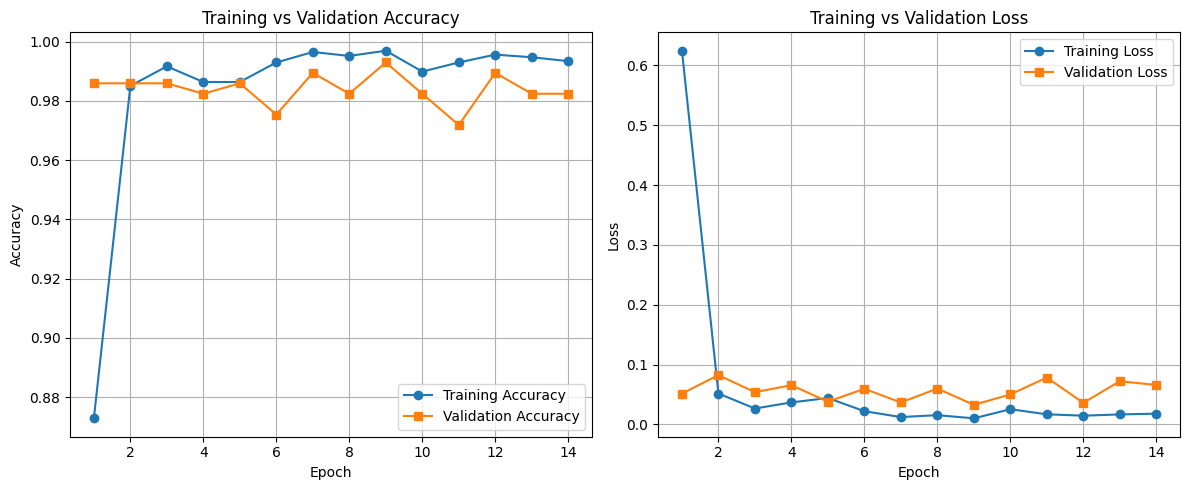

In [ ]:
# === Ekstrak data dari history ===
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

# === Plot Akurasi ===
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='s')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# === Plot Loss ===
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='s')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step


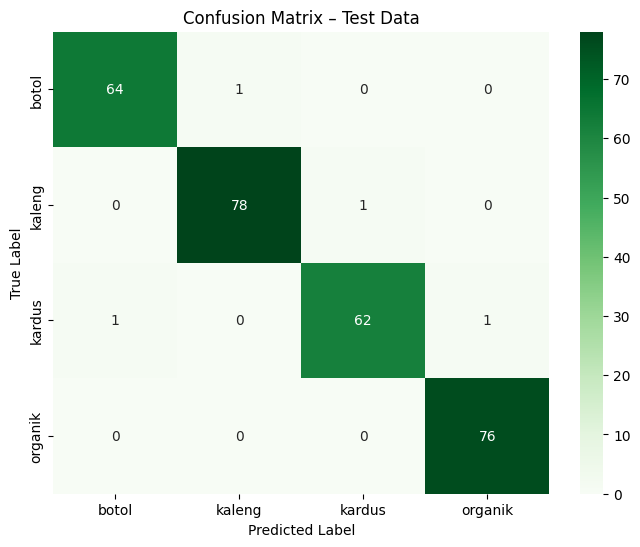

=== Classification Report (Test Data) ===
              precision    recall  f1-score   support

       botol       0.98      0.98      0.98        65
      kaleng       0.99      0.99      0.99        79
      kardus       0.98      0.97      0.98        64
     organik       0.99      1.00      0.99        76

    accuracy                           0.99       284
   macro avg       0.99      0.99      0.99       284
weighted avg       0.99      0.99      0.99       284

4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.9859 - loss: 0.0744

Test Accuracy: 98.59%
Test Loss: 0.0744


In [ ]:

# ====== TESTING MODEL PADA DATA TEST SET ======
# 🔹 Pastikan generator tidak diacak
test_gen.shuffle = False

# 🔹 Prediksi seluruh data test
Y_test_pred = model.predict(test_gen)
y_test_pred = np.argmax(Y_test_pred, axis=1)

# 🔹 Label asli
y_test_true = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

# ===== Confusion Matrix =====
cm_test = confusion_matrix(y_test_true, y_test_pred)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix – Test Data')
plt.show()

# ===== Classification Report =====
print("=== Classification Report (Test Data) ===")
print(classification_report(y_test_true, y_test_pred, target_names=class_labels))

# ===== Akurasi Keseluruhan =====
test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")
